# Import libs

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CyclicLR, StepLR
from torch.optim import Adam

from tqdm import tqdm
from IPython.display import clear_output
from sklearn.preprocessing import normalize
from sklearn.preprocessing import scale
import math

from torch.utils.data import DataLoader, Dataset

In [2]:
import sys

sys.path.append("../..")

In [3]:
from src.data.changepoints_generators.changepoint_generators import SyntheticSinusoid, LinearSteps

# Define Args

In [4]:
SEQUENCE_LENGTH = 120
EMBED_DIM = 504
N_HEADS = 6
N_LAYERS = 6

NUMBER_DATASET_TRAINING=20000
NUMBER_DATASET_VALIDATION=2000
INPUT_DIM = 1

EPOCHS = 150
BATCH_SIZE = 64
NUM_WORKERS = 5

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

cuda:0
NVIDIA GeForce RTX 3060 Laptop GPU


From the AnomalyBERT paper:

    "Unlike the original Transformer or ViT, we do not use sinusoidal positional encodings or absolute position embeddings to inject positional information. We instead add 1D relative position bias to each attention matrix to consider the relative positions between features in a window."


# Define Neural Network

In [5]:
# --- Relative Position Bias Module ---
class RelativePositionBias(nn.Module):
    def __init__(self, seq_len, num_heads):
        super().__init__()
        self.seq_len = seq_len
        self.num_heads = num_heads
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * seq_len - 1), num_heads)
        )
        coords = torch.arange(seq_len)
        relative_coords = coords[None, :] - coords[:, None]
        relative_coords += seq_len - 1
        self.register_buffer("relative_position_index", relative_coords)

    def forward(self):
        # shape: (num_heads, seq_len, seq_len)
        bias = self.relative_position_bias_table[self.relative_position_index]
        return bias.permute(2, 0, 1)

# --- Self-Attention with Relative Position Bias ---
class RelPosAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, seq_len, dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.seq_len = seq_len
        self.head_dim = embed_dim // num_heads
        assert embed_dim % num_heads == 0
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.rel_pos_bias = RelativePositionBias(seq_len, num_heads)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.unbind(2)  # Each (B, T, num_heads, head_dim)
        q = q.permute(0, 2, 1, 3)  # (B, num_heads, T, head_dim)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)
        attn = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        rel_bias = self.rel_pos_bias()  # (num_heads, T, T)
        attn = attn + rel_bias.unsqueeze(0)
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = attn @ v        # (B, num_heads, T, head_dim)
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.proj(out)

# --- Transformer Encoder Block ---
class Block(nn.Module):
    def __init__(self, embed_dim, num_heads, seq_len, mlp_hidden_dim=2048, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = RelPosAttention(embed_dim, num_heads, seq_len, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, embed_dim),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

# --- Main AnomalyBERT Model ---
class AnomalyBERT(nn.Module):
    def __init__(self, input_dim, embed_dim=512, num_heads=8, seq_len=512, num_layers=6, mlp_hidden_dim=2048, patch_size=1):
        super().__init__()
        self.seq_len = seq_len
        self.patch_size = patch_size

        # Linear embedding for patches
        self.embed = nn.Linear(input_dim * patch_size, embed_dim)

        # Transformer body
        self.transformer = nn.ModuleList([
            Block(embed_dim, num_heads, seq_len, mlp_hidden_dim) for _ in range(num_layers)
        ])

        # Prediction block (outputs 1 anomaly score per input point in window)
        self.pred_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, 1),    # predicts anomaly score per timestep
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: (B, seq_len, input_dim)
        B, T, C = x.shape
        if self.patch_size > 1:
            # Merge patches if needed (optional; not always used with patch_size=1)
            x = x.unfold(1, self.patch_size, self.patch_size)  # (B, new_T, patch_size, C)
            x = x.contiguous().view(B, -1, C * self.patch_size)
        # Embedding
        emb = self.embed(x)  # (B, T, embed_dim)
        # Transformer blocks
        h = emb
        for blk in self.transformer:
            h = blk(h)
        # Output anomaly scores for each point (B, T, 1)
        scores = self.pred_head(h).squeeze(-1)
        return scores

# Generate Data

In [6]:
class TimeSeries(Dataset):
    def __init__(self, time_series, sequence_length_nn: int = 72):
        self.time_series = time_series
        self.sequence_length_nn = sequence_length_nn
    
    def normalize_by_minmax(self, data: np.array) -> np.array:
        return (data-data.min())/(data.max()-data.min())

    def __getitem__(self, idx):
        y, x = self.time_series[idx]
        
        x = self.normalize_by_minmax(x)
        return torch.Tensor(x).unsqueeze(-1), torch.Tensor(y)

    def __len__(self):
        return len(self.time_series)

In [7]:
def generate_some_training_data(number_datasets=1000,
                                cps_number_list=[1, 2, 5, 6,],
                                length_data_list=[256]) -> list:
    time_series = []
    for val in range(number_datasets):
        if random.randint(a=0, b=1):
            data_obj = SyntheticSinusoid(
                length_data=random.choice(length_data_list),
                cps_number=random.choice(cps_number_list))
            y, x = data_obj.get()
        else:
            data_obj = LinearSteps(
                length_data=random.choice(length_data_list),
                cps_number=random.choice(cps_number_list))
            y, x, _ = data_obj.get()
        time_series.append((y, x))
    return time_series

In [8]:
train_loader = DataLoader(
    TimeSeries(time_series=generate_some_training_data(number_datasets=NUMBER_DATASET_TRAINING, length_data_list=[SEQUENCE_LENGTH])),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

valid_loader = DataLoader(
    TimeSeries(time_series=generate_some_training_data(number_datasets=NUMBER_DATASET_VALIDATION, length_data_list=[SEQUENCE_LENGTH])),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

# Define Tran & Validation pipeline

In [9]:
def train(model, loader):
    model.train()

    train_loss = 0

    for x_en, y in tqdm(loader, desc='Training'):
        x_en, y = x_en.to(device), y.to(device)
        optimizer.zero_grad()

        output = model(x_en)

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0

    for x_en, y in tqdm(loader, desc='Evaluation'):
        x_en, y = x_en.to(device), y.to(device)

        output = model(x_en)

        loss = loss_fn(output, y)

        total_loss += loss.item()

    total_loss /= len(loader)

    return total_loss

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

def whole_train_valid_cycle(model, num_epochs, title, scheduler):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait=True)

        scheduler.step()

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

# Training SetUP

In [10]:
model = AnomalyBERT(input_dim=1, embed_dim=EMBED_DIM, num_heads=N_HEADS, seq_len=SEQUENCE_LENGTH, num_layers=N_LAYERS).to(device)

In [11]:
model

AnomalyBERT(
  (embed): Linear(in_features=1, out_features=504, bias=True)
  (transformer): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm((504,), eps=1e-05, elementwise_affine=True)
      (attn): RelPosAttention(
        (qkv): Linear(in_features=504, out_features=1512, bias=False)
        (proj): Linear(in_features=504, out_features=504, bias=True)
        (rel_pos_bias): RelativePositionBias()
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ln2): LayerNorm((504,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=504, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=504, bias=True)
      )
    )
  )
  (pred_head): Sequential(
    (0): LayerNorm((504,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=504, out_features=2048, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=2048, out_features=1, bias=True)
   

In [12]:
optimizer = Adam(model.parameters(), lr=5e-4, weight_decay=0.4, foreach=False)
loss_fn = nn.BCELoss(reduction="sum")

In [13]:
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

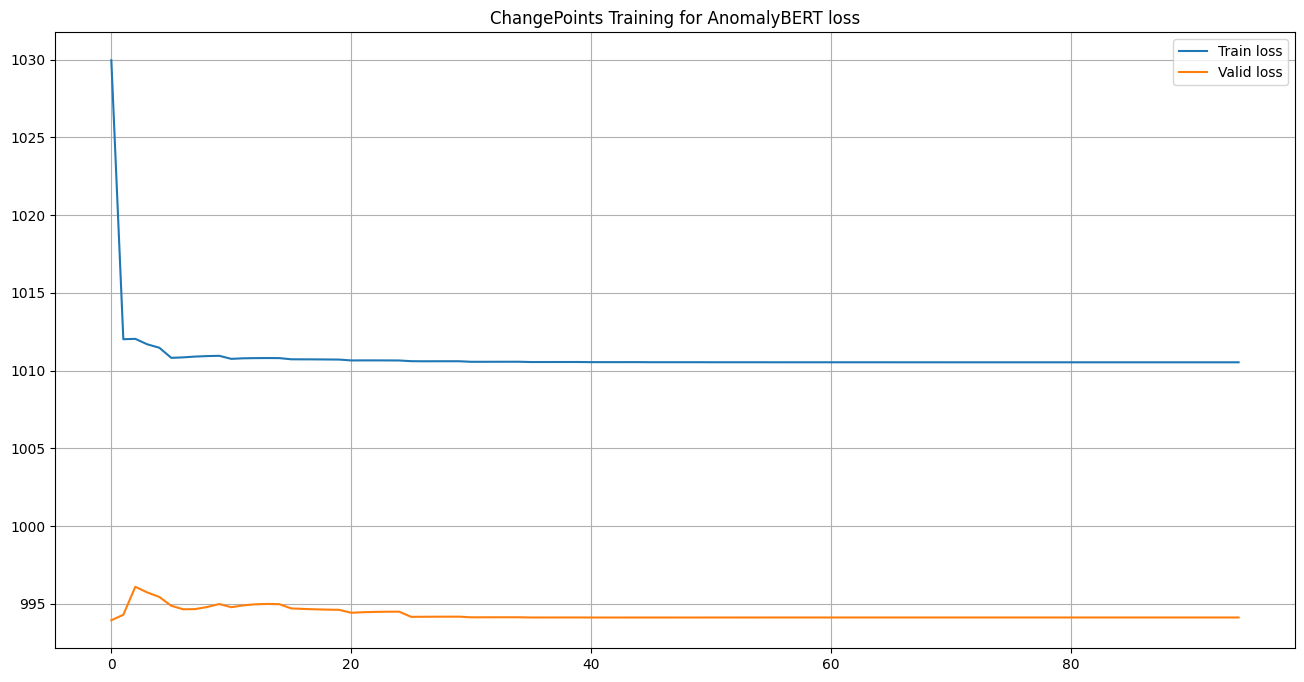

Training:  53%|███████████████████████████████████████████████████████████▌                                                     | 165/313 [00:43<00:38,  3.83it/s]


KeyboardInterrupt: 

In [14]:
whole_train_valid_cycle(model, EPOCHS, 'ChangePoints Training for AnomalyBERT', scheduler)

# Plot results over validation data

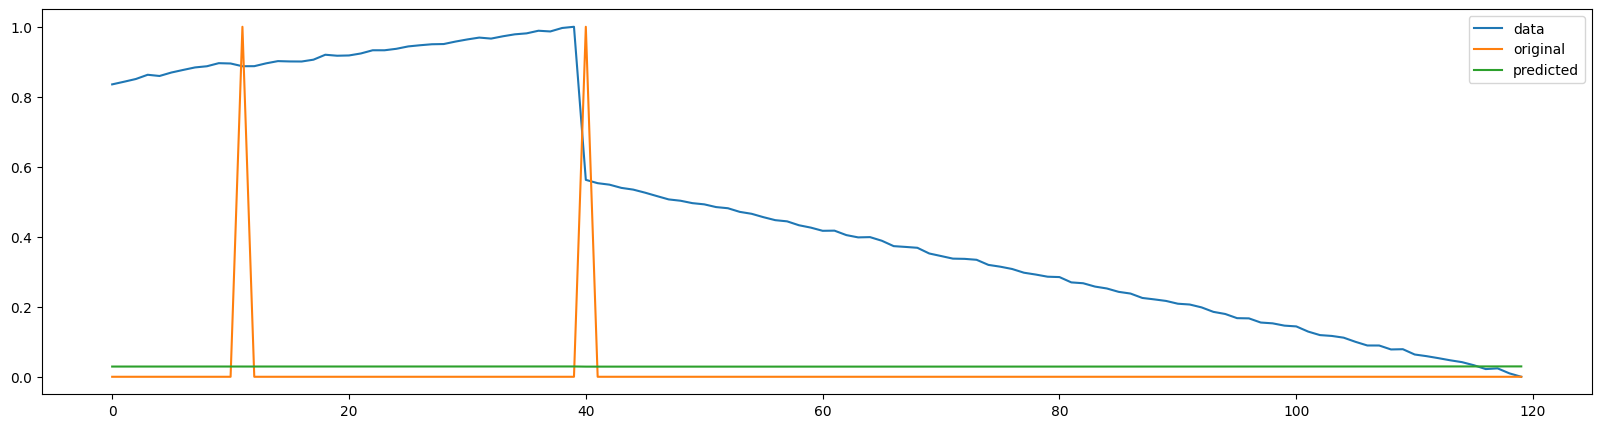

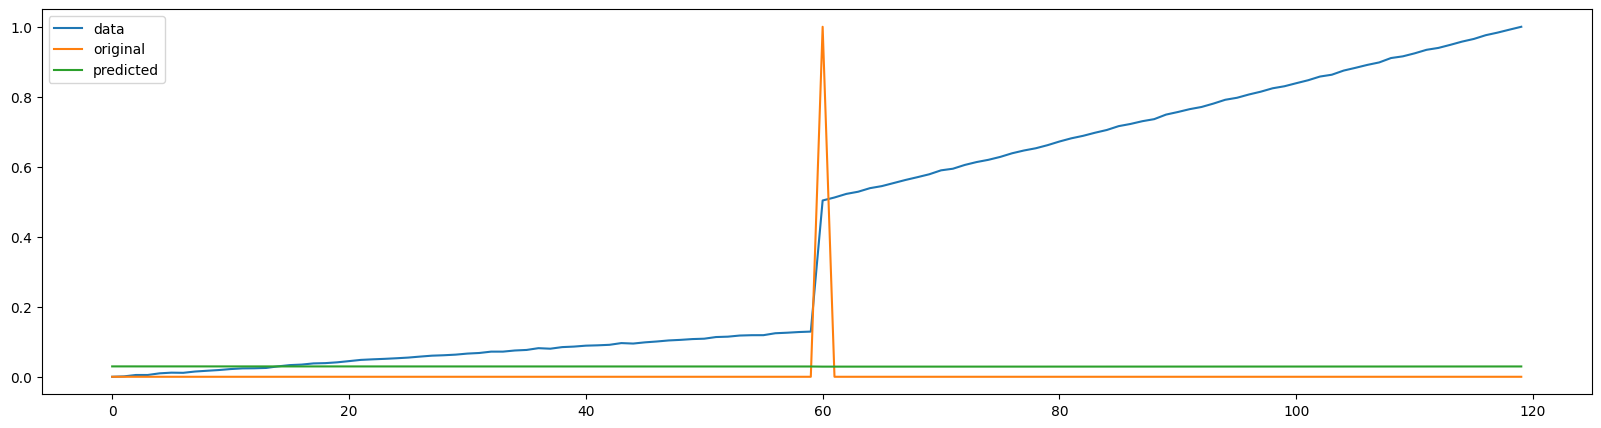

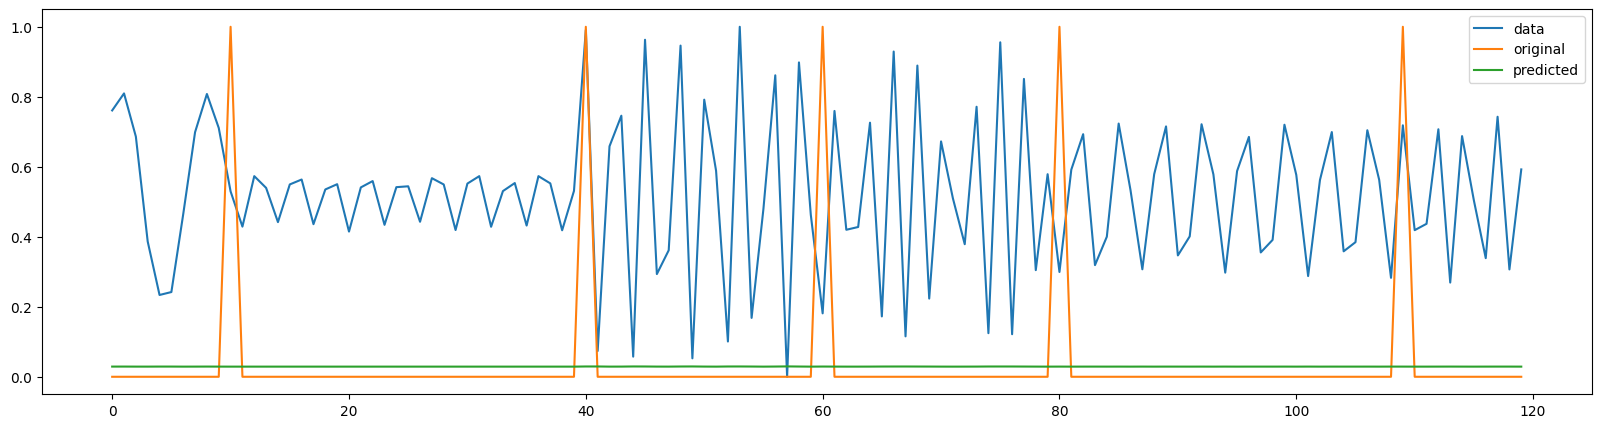

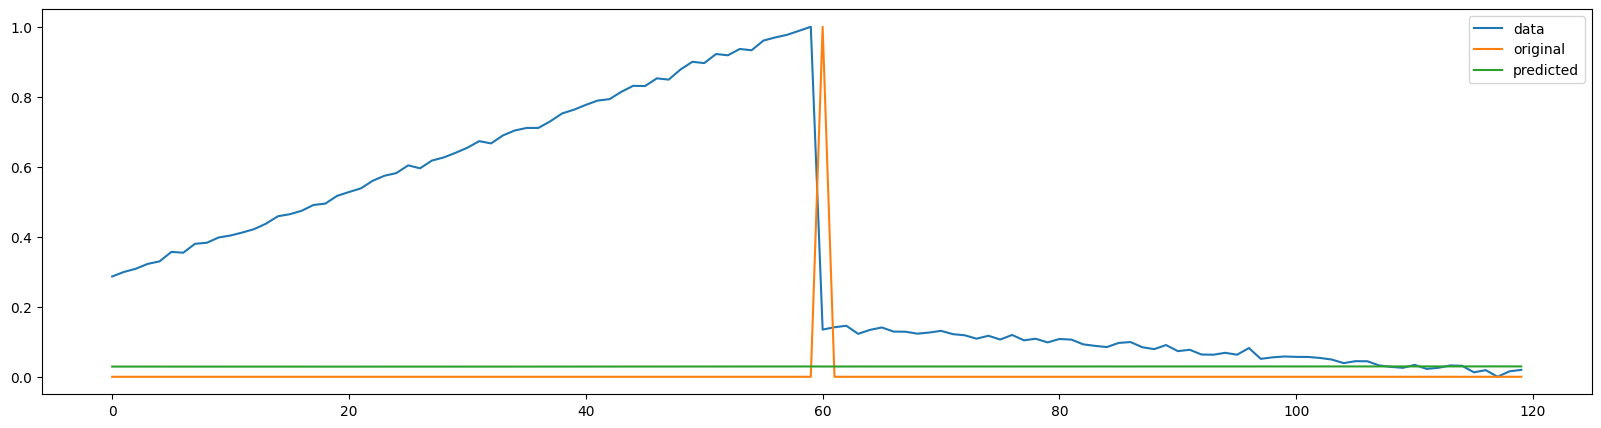

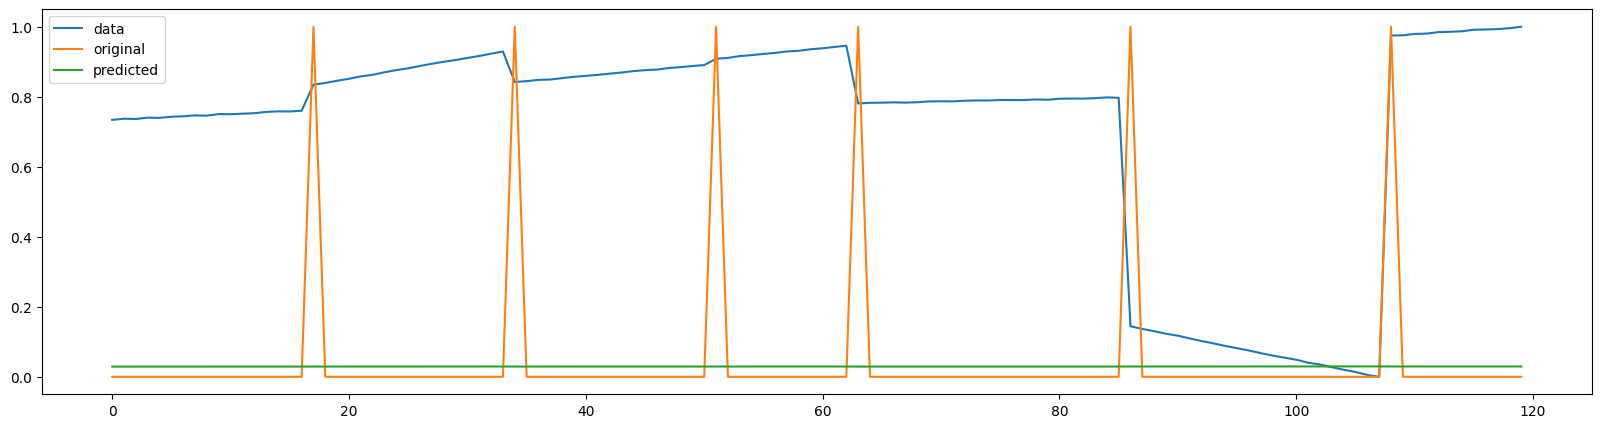

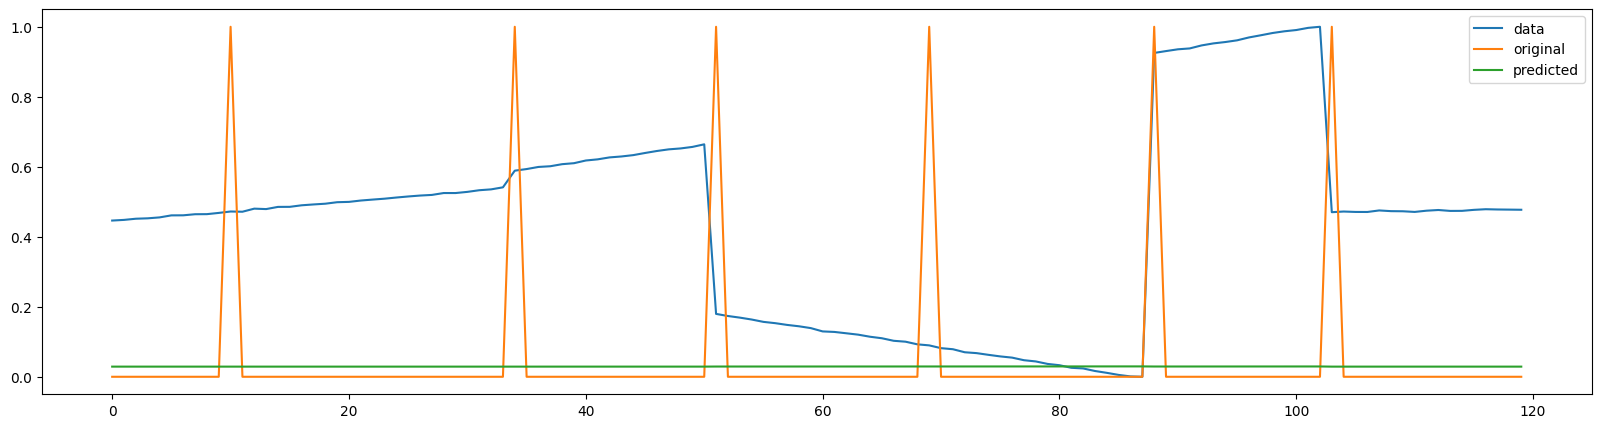

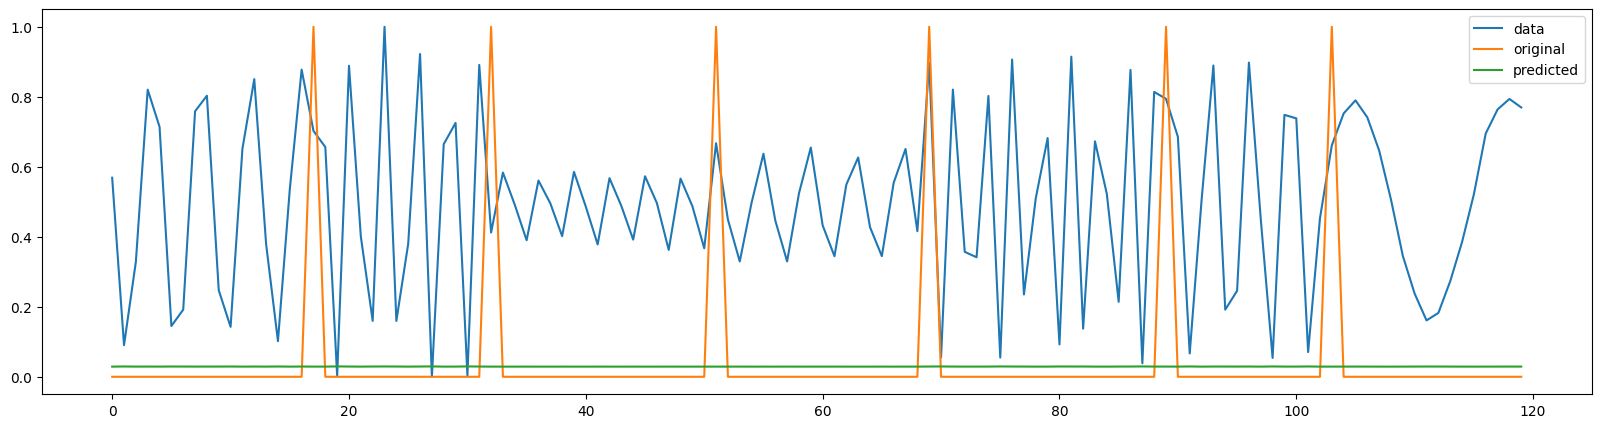

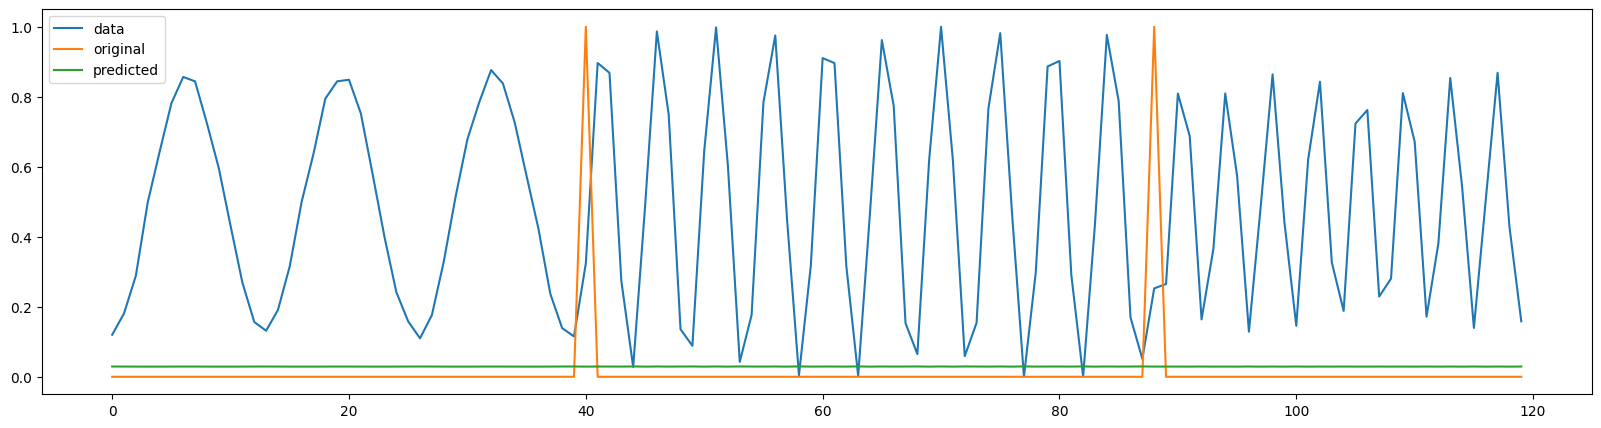

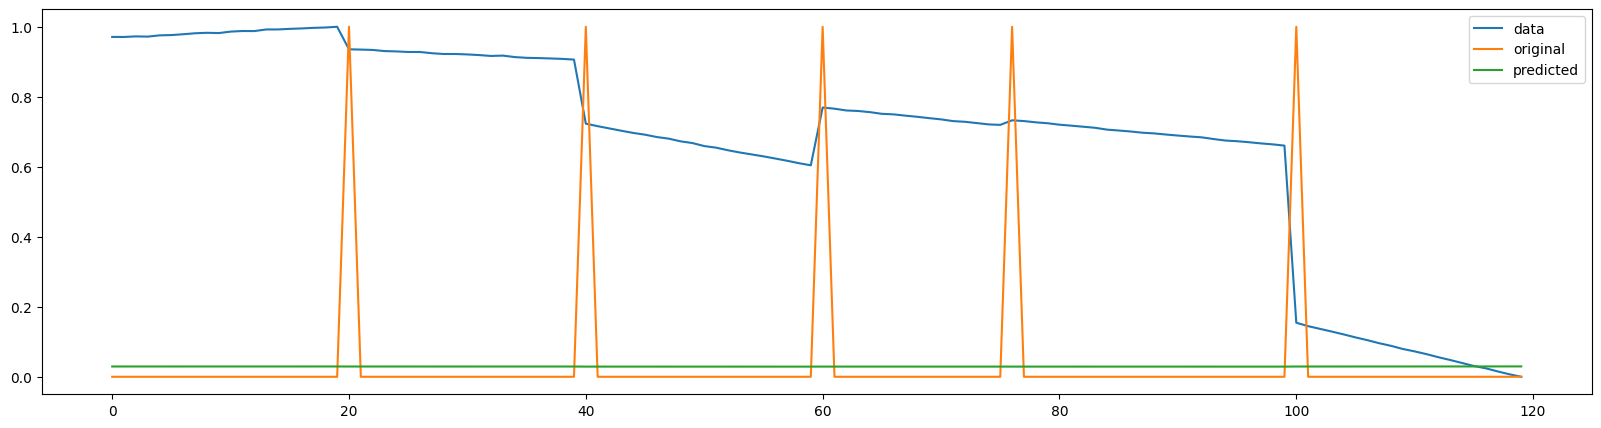

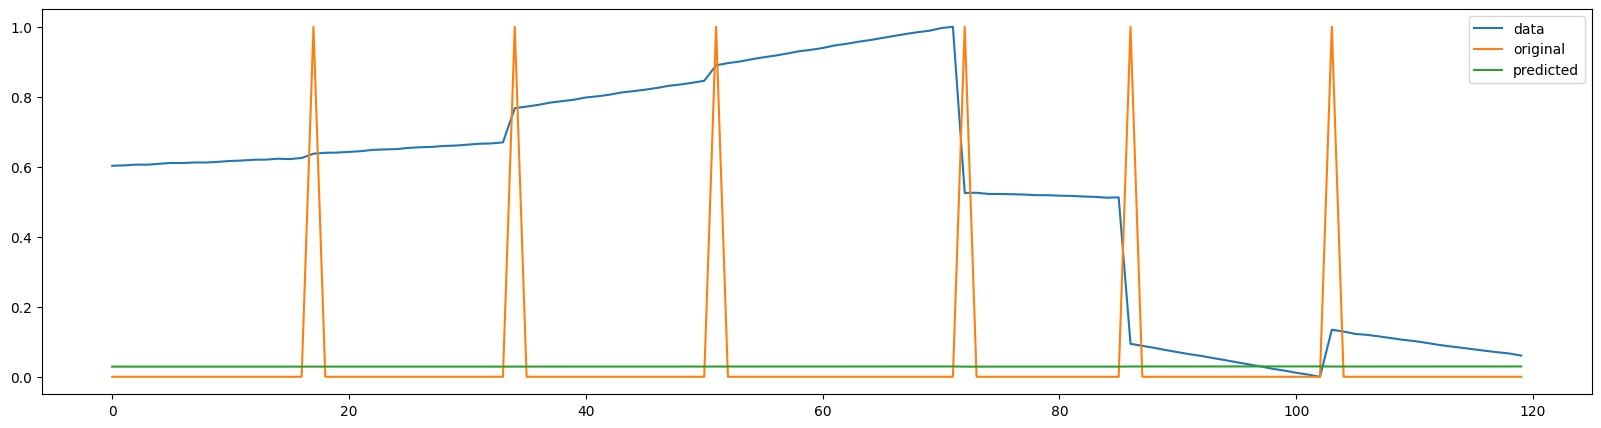

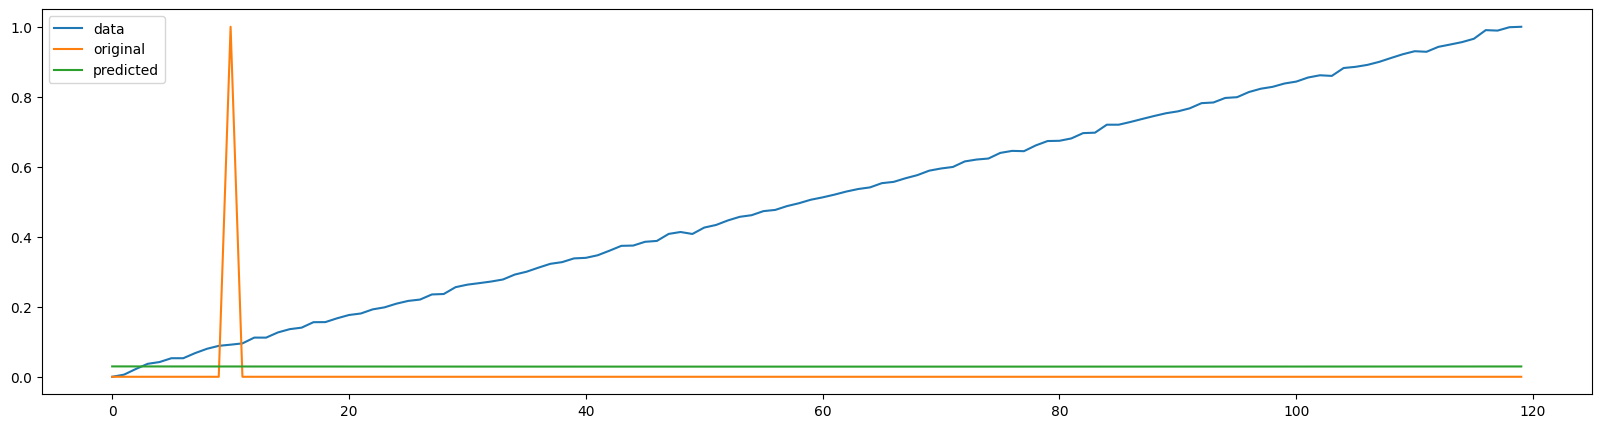

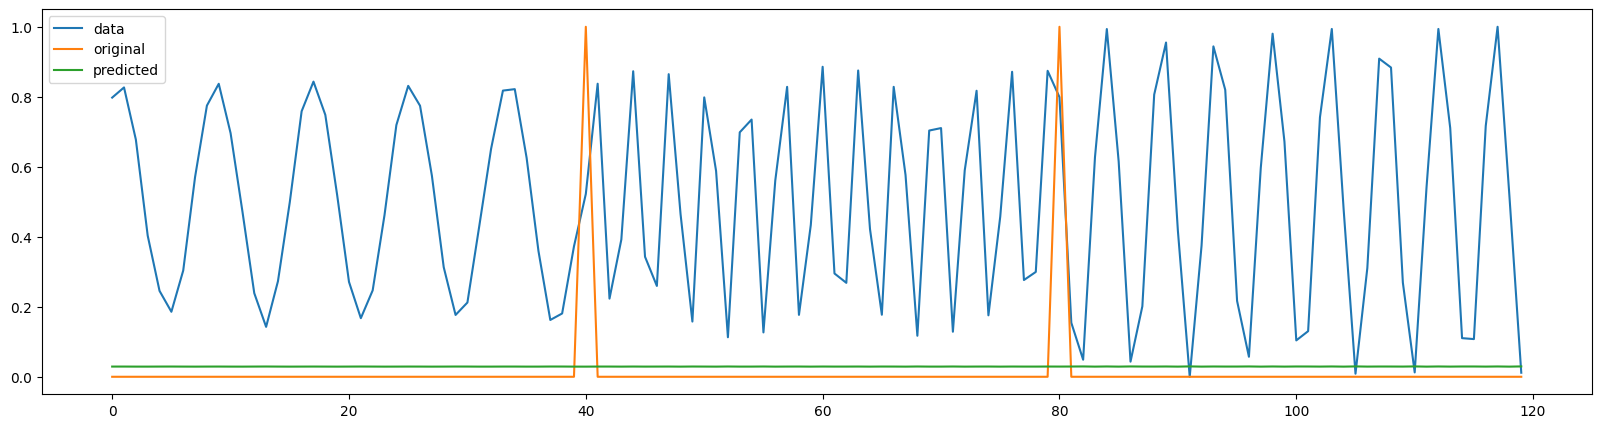

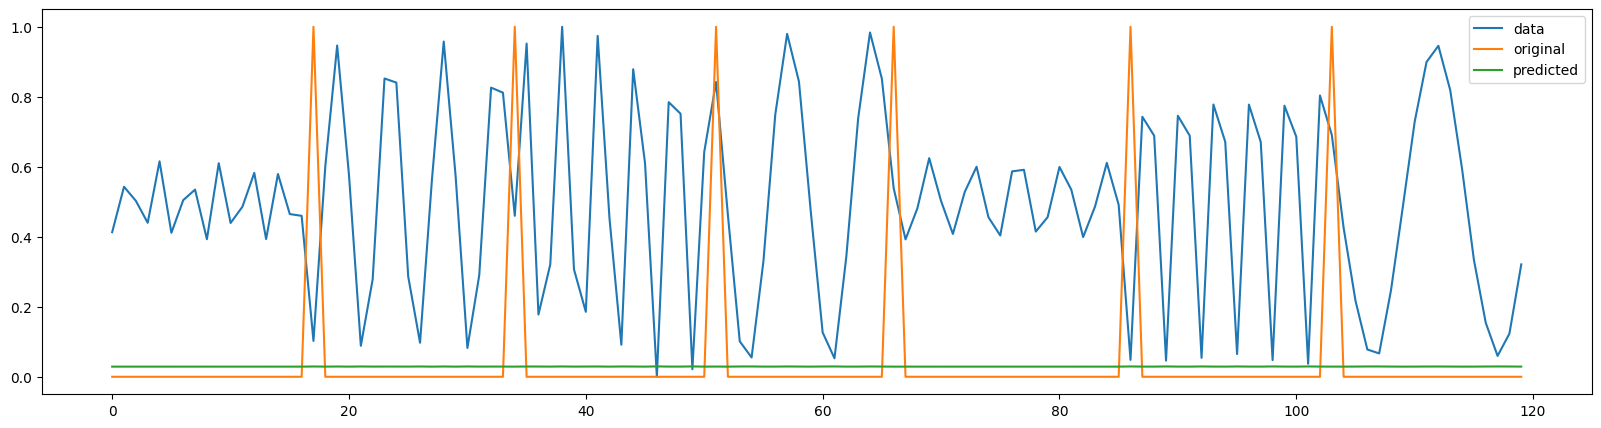

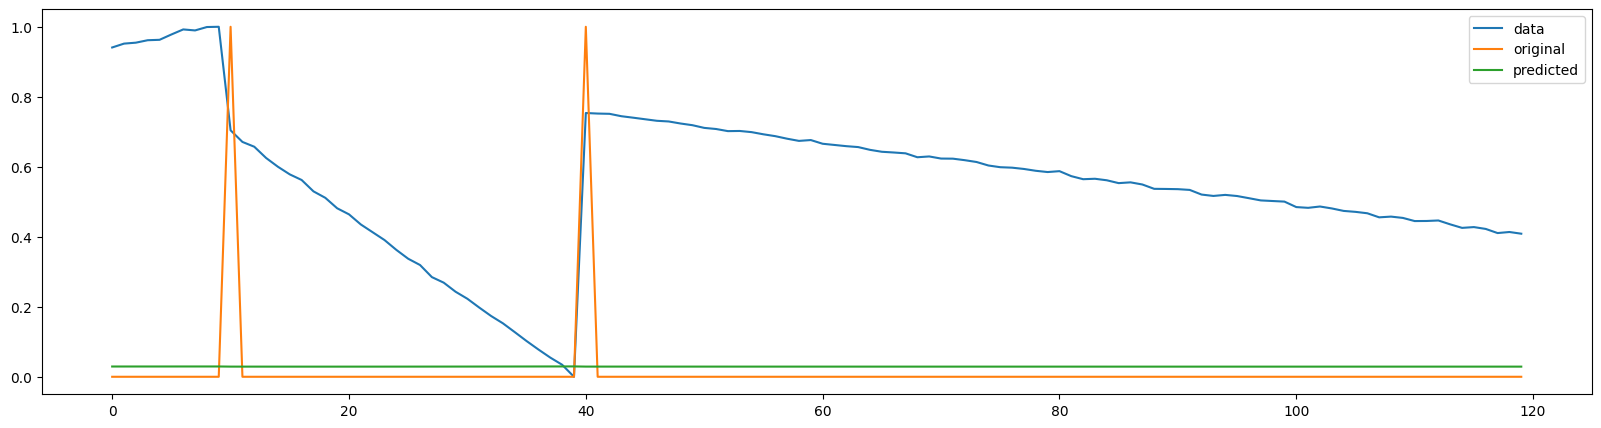

In [15]:
for test_x, test_y in iter(valid_loader):
    counter = 0
    for val in range(BATCH_SIZE):
        counter += 1
        
        plt.figure(figsize=(20,5))
        plt.plot(test_x[counter].flatten(), label="data")
        plt.plot(test_y[counter].flatten(), label='original')
        plt.plot(model(test_x[counter].unsqueeze(0).to(device)).flatten().to("cpu").detach(), label='predicted')
        plt.legend()
        
        if counter >= 14:
            break
    break